# ShotGuide CLIP Embedding Baseline

This notebook extracts frozen CLIP ViT-B/32 image embeddings and trains a small multi-task head on top of them.

- Uses the existing video-level split from `outputs_baseline/dataset_index_with_splits.csv`
- Extracts one 512-dim CLIP embedding per labeled image
- Saves embeddings for reuse
- Trains heads for `shot_type` and `has_text`


In [1]:
from pathlib import Path
from collections import Counter
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm.auto import tqdm
import open_clip

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

ROOT = Path.cwd()
SPLIT_CSV = ROOT / 'outputs_baseline' / 'dataset_index_with_splits.csv'
OUTPUT_DIR = ROOT / 'outputs_clip_embeddings'
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

C:\Users\user\anaconda3\envs\shotguide-baseline\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

## 1. Load the Fixed Split

The split is reused from the previous ResNet baseline so the comparison remains fair.

In [2]:
df = pd.read_csv(SPLIT_CSV)
df['has_text'] = df['has_text'].astype(int)

valid_splits = {'train', 'val', 'test'}
assert set(df['split'].unique()) == valid_splits, df['split'].unique()

leaks = [video_id for video_id, g in df.groupby('video_id') if g['split'].nunique() > 1]
print('rows:', len(df))
print('videos:', df['video_id'].nunique())
print('group leakage count:', len(leaks))
assert len(leaks) == 0

display(pd.crosstab(df['joint_label'], df['split']))
display(df.head())

rows: 1188
videos: 129
group leakage count: 0


split,test,train,val
joint_label,,,
close-up_notext,4,24,1
close-up_text,26,76,16
medium_notext,6,45,23
medium_text,79,189,63
object_notext,4,30,5
object_text,58,148,51
space_notext,5,19,4
space_text,22,60,14
wide_notext,23,48,2


,filepath,filename,video_id,original_class,shot_type,has_text,joint_label,split
0,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_006.jpg,13,close-up_notext,close-up,0,close-up_notext,train
1,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_012.jpg,13,close-up_notext,close-up,0,close-up_notext,train
2,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_017.jpg,13,close-up_notext,close-up,0,close-up_notext,train
3,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0015_cut_001.jpg,15,close-up_notext,close-up,0,close-up_notext,train
4,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0024_cut_012.jpg,24,close-up_notext,close-up,0,close-up_notext,train


## 2. Load Frozen CLIP ViT-B/32

The first run may download pretrained OpenAI CLIP weights.

In [3]:
MODEL_NAME = 'ViT-B-32'
PRETRAINED = 'openai'

model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME, pretrained=PRETRAINED, device=DEVICE)
model.eval()

for param in model.parameters():
    param.requires_grad = False

print('model:', MODEL_NAME, PRETRAINED)
print('embedding dim:', model.visual.output_dim)

C:\Users\user\anaconda3\envs\shotguide-baseline\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--timm--vit_base_patch32_clip_224.openai. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\user\anaconda3\envs\shotguide-baseline\lib\site-packages\open_clip\factory.

model: ViT-B-32 openai
embedding dim: 512


## 3. Extract and Save CLIP Embeddings

In [4]:
class ImagePathDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        path = self.frame.loc[idx, 'filepath']
        image = Image.open(path).convert('RGB')
        return self.transform(image), idx

EMBEDDING_NPZ = OUTPUT_DIR / 'clip_vit_b32_openai_embeddings.npz'
EMBEDDING_META_CSV = OUTPUT_DIR / 'clip_embedding_metadata.csv'

if EMBEDDING_NPZ.exists() and EMBEDDING_META_CSV.exists():
    print('Loading cached embeddings:', EMBEDDING_NPZ)
    cached = np.load(EMBEDDING_NPZ)
    embeddings = cached['embeddings']
else:
    loader = DataLoader(ImagePathDataset(df, preprocess), batch_size=64, shuffle=False, num_workers=0)
    embedding_chunks = []
    order = []

    with torch.no_grad():
        for images, indices in tqdm(loader):
            images = images.to(DEVICE)
            features = model.encode_image(images)
            features = features / features.norm(dim=-1, keepdim=True)
            embedding_chunks.append(features.cpu().float().numpy())
            order.extend(indices.numpy().tolist())

    embeddings = np.concatenate(embedding_chunks, axis=0).astype('float32')
    order = np.array(order)
    assert np.all(order == np.arange(len(df)))

    np.savez_compressed(
        EMBEDDING_NPZ,
        embeddings=embeddings,
        has_text=df['has_text'].to_numpy(dtype=np.int64),
        split=df['split'].to_numpy(),
        shot_type=df['shot_type'].to_numpy(),
        filepath=df['filepath'].to_numpy(),
    )
    df.assign(embedding_index=np.arange(len(df))).to_csv(EMBEDDING_META_CSV, index=False, encoding='utf-8-sig')

print('embedding shape:', embeddings.shape)
print('saved:', EMBEDDING_NPZ)

  0%|          | 0/19 [00:00<?, ?it/s]

  5%|▌         | 1/19 [00:01<00:33,  1.87s/it]

 11%|█         | 2/19 [00:03<00:31,  1.84s/it]

 16%|█▌        | 3/19 [00:05<00:29,  1.87s/it]

 21%|██        | 4/19 [00:07<00:28,  1.93s/it]

...

 89%|████████▉ | 17/19 [00:36<00:04,  2.34s/it]

 95%|█████████▍| 18/19 [00:38<00:02,  2.36s/it]

100%|██████████| 19/19 [00:39<00:00,  2.07s/it]

100%|██████████| 19/19 [00:39<00:00,  2.10s/it]

embedding shape: (1188, 512)
saved: C:\Temp\deep\outputs_clip_embeddings\clip_vit_b32_openai_embeddings.npz


## 4. Train a Multi-task Head on Frozen Embeddings

In [5]:
SHOT_TYPES = ['close-up', 'medium', 'object', 'space', 'wide']
shot_to_idx = {name: i for i, name in enumerate(SHOT_TYPES)}
idx_to_shot = {i: name for name, i in shot_to_idx.items()}

shot_labels = df['shot_type'].map(shot_to_idx).to_numpy(dtype=np.int64)
text_labels = df['has_text'].to_numpy(dtype=np.int64)

def split_arrays(split_name):
    mask = df['split'].to_numpy() == split_name
    x = torch.tensor(embeddings[mask], dtype=torch.float32)
    y_shot = torch.tensor(shot_labels[mask], dtype=torch.long)
    y_text = torch.tensor(text_labels[mask], dtype=torch.long)
    return x, y_shot, y_text, mask

x_train, y_shot_train, y_text_train, train_mask = split_arrays('train')
x_val, y_shot_val, y_text_val, val_mask = split_arrays('val')
x_test, y_shot_test, y_text_test, test_mask = split_arrays('test')

train_loader = DataLoader(TensorDataset(x_train, y_shot_train, y_text_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_shot_val, y_text_val), batch_size=256, shuffle=False)
test_loader = DataLoader(TensorDataset(x_test, y_shot_test, y_text_test), batch_size=256, shuffle=False)

x_train.shape, x_val.shape, x_test.shape

(torch.Size([721, 512]), torch.Size([208, 512]), torch.Size([259, 512]))

In [6]:
class ClipEmbeddingMultiTaskHead(nn.Module):
    def __init__(self, embedding_dim=512, hidden_dim=256, num_shot_classes=5, dropout=0.20):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.shot_head = nn.Linear(hidden_dim, num_shot_classes)
        self.text_head = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        z = self.shared(x)
        return self.shot_head(z), self.text_head(z)

def make_class_weights(labels, num_classes):
    counts = Counter(labels.tolist())
    total = sum(counts.values())
    return torch.tensor([total / (num_classes * max(counts.get(i, 0), 1)) for i in range(num_classes)], dtype=torch.float32)

head = ClipEmbeddingMultiTaskHead(embedding_dim=embeddings.shape[1], hidden_dim=256).to(DEVICE)
shot_criterion = nn.CrossEntropyLoss(weight=make_class_weights(y_shot_train, len(SHOT_TYPES)).to(DEVICE))
text_criterion = nn.CrossEntropyLoss(weight=make_class_weights(y_text_train, 2).to(DEVICE))
optimizer = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=1e-3)

TEXT_LOSS_WEIGHT = 1.0
EPOCHS = 80
PATIENCE = 12

def evaluate(loader):
    head.eval()
    total_loss = 0.0
    shot_true, shot_pred = [], []
    text_true, text_pred = [], []
    with torch.no_grad():
        for x, y_shot, y_text in loader:
            x = x.to(DEVICE)
            y_shot = y_shot.to(DEVICE)
            y_text = y_text.to(DEVICE)
            shot_logits, text_logits = head(x)
            loss = shot_criterion(shot_logits, y_shot) + TEXT_LOSS_WEIGHT * text_criterion(text_logits, y_text)
            total_loss += loss.item() * x.size(0)
            shot_true.extend(y_shot.cpu().numpy().tolist())
            shot_pred.extend(shot_logits.argmax(1).cpu().numpy().tolist())
            text_true.extend(y_text.cpu().numpy().tolist())
            text_pred.extend(text_logits.argmax(1).cpu().numpy().tolist())
    return {
        'loss': total_loss / len(loader.dataset),
        'shot_acc': accuracy_score(shot_true, shot_pred),
        'shot_macro_f1': f1_score(shot_true, shot_pred, average='macro', zero_division=0),
        'text_acc': accuracy_score(text_true, text_pred),
        'text_f1': f1_score(text_true, text_pred, average='binary', zero_division=0),
        'joint_acc': np.mean((np.array(shot_true) == np.array(shot_pred)) & (np.array(text_true) == np.array(text_pred))),
    }

def train_one_epoch(loader):
    head.train()
    for x, y_shot, y_text in loader:
        x = x.to(DEVICE)
        y_shot = y_shot.to(DEVICE)
        y_text = y_text.to(DEVICE)
        shot_logits, text_logits = head(x)
        loss = shot_criterion(shot_logits, y_shot) + TEXT_LOSS_WEIGHT * text_criterion(text_logits, y_text)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

history = []
best_state = None
best_val_joint = -1.0
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_one_epoch(train_loader)
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}}
    history.append(row)
    if epoch == 1 or epoch % 5 == 0:
        print(row)

    if val_metrics['joint_acc'] > best_val_joint:
        best_val_joint = val_metrics['joint_acc']
        best_state = {k: v.detach().cpu().clone() for k, v in head.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print('Early stopping at epoch', epoch)
            break

head.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'clip_head_training_history.csv', index=False)

checkpoint_path = OUTPUT_DIR / 'clip_vit_b32_multitask_head.pt'
torch.save({
    'model_state_dict': best_state,
    'shot_to_idx': shot_to_idx,
    'idx_to_shot': idx_to_shot,
    'clip_model': MODEL_NAME,
    'clip_pretrained': PRETRAINED,
}, checkpoint_path)

print('best val joint acc:', best_val_joint)
print('saved:', checkpoint_path)
history_df.tail()

{'epoch': 1, 'train_loss': 2.2240607811243955, 'train_shot_acc': 0.5866851595006934, 'train_shot_macro_f1': 0.4562155948058672, 'train_text_acc': 0.8016643550624133, 'train_text_f1': 0.8682027649769585, 'train_joint_acc': np.float64(0.46879334257975036), 'val_loss': 2.226681709289551, 'val_shot_acc': 0.5, 'val_shot_macro_f1': 0.33598930889299417, 'val_text_acc': 0.8173076923076923, 'val_text_f1': 0.8914285714285715, 'val_joint_acc': np.float64(0.39903846153846156)}


{'epoch': 5, 'train_loss': 1.5659448539995784, 'train_shot_acc': 0.6851595006934813, 'train_shot_macro_f1': 0.662373709094378, 'train_text_acc': 0.7850208044382802, 'train_text_f1': 0.8448448448448449, 'train_joint_acc': np.float64(0.5353675450762829), 'val_loss': 1.7303047180175781, 'val_shot_acc': 0.5865384615384616, 'val_shot_macro_f1': 0.5042165109414924, 'val_text_acc': 0.7788461538461539, 'val_text_f1': 0.8580246913580247, 'val_joint_acc': np.float64(0.46153846153846156)}


{'epoch': 10, 'train_loss': 1.0206596970392827, 'train_shot_acc': 0.7850208044382802, 'train_shot_macro_f1': 0.7792333171717526, 'train_text_acc': 0.8391123439667129, 'train_text_f1': 0.88671875, 'train_joint_acc': np.float64(0.6629680998613038), 'val_loss': 1.3611513376235962, 'val_shot_acc': 0.6394230769230769, 'val_shot_macro_f1': 0.5932401897466848, 'val_text_acc': 0.7836538461538461, 'val_text_f1': 0.8615384615384616, 'val_joint_acc': np.float64(0.5240384615384616)}


{'epoch': 15, 'train_loss': 0.766233940726345, 'train_shot_acc': 0.8280166435506241, 'train_shot_macro_f1': 0.8230439314522023, 'train_text_acc': 0.8793342579750347, 'train_text_f1': 0.9164265129682997, 'train_joint_acc': np.float64(0.7281553398058253), 'val_loss': 1.2061529159545898, 'val_shot_acc': 0.6634615384615384, 'val_shot_macro_f1': 0.630215639900188, 'val_text_acc': 0.7836538461538461, 'val_text_f1': 0.8623853211009175, 'val_joint_acc': np.float64(0.5432692307692307)}


{'epoch': 20, 'train_loss': 0.6181467678940412, 'train_shot_acc': 0.8613037447988904, 'train_shot_macro_f1': 0.8557676637263526, 'train_text_acc': 0.9084604715672677, 'train_text_f1': 0.937381404174573, 'train_joint_acc': np.float64(0.782246879334258), 'val_loss': 1.150015950202942, 'val_shot_acc': 0.6826923076923077, 'val_shot_macro_f1': 0.6472536852818542, 'val_text_acc': 0.7932692307692307, 'val_text_f1': 0.8676923076923077, 'val_joint_acc': np.float64(0.5576923076923077)}


...

{'epoch': 30, 'train_loss': 0.43843149671772813, 'train_shot_acc': 0.9070735090152566, 'train_shot_macro_f1': 0.9060620039227765, 'train_text_acc': 0.9223300970873787, 'train_text_f1': 0.947069943289225, 'train_joint_acc': np.float64(0.8363384188626907), 'val_loss': 1.1494061946868896, 'val_shot_acc': 0.7115384615384616, 'val_shot_macro_f1': 0.6753663003663003, 'val_text_acc': 0.8076923076923077, 'val_text_f1': 0.8780487804878049, 'val_joint_acc': np.float64(0.5913461538461539)}


{'epoch': 35, 'train_loss': 0.3734689706241539, 'train_shot_acc': 0.9334257975034674, 'train_shot_macro_f1': 0.9321767202813641, 'train_text_acc': 0.9403606102635229, 'train_text_f1': 0.96, 'train_joint_acc': np.float64(0.8793342579750347), 'val_loss': 1.1805977821350098, 'val_shot_acc': 0.7211538461538461, 'val_shot_macro_f1': 0.6821551569045723, 'val_text_acc': 0.8125, 'val_text_f1': 0.8814589665653495, 'val_joint_acc': np.float64(0.6057692307692307)}


{'epoch': 40, 'train_loss': 0.32146136225013894, 'train_shot_acc': 0.9445214979195562, 'train_shot_macro_f1': 0.9451925509658132, 'train_text_acc': 0.9348127600554785, 'train_text_f1': 0.955868544600939, 'train_joint_acc': np.float64(0.883495145631068), 'val_loss': 1.1924567222595215, 'val_shot_acc': 0.7163461538461539, 'val_shot_macro_f1': 0.6780685420550854, 'val_text_acc': 0.8125, 'val_text_f1': 0.8814589665653495, 'val_joint_acc': np.float64(0.6009615384615384)}


Early stopping at epoch 43
best val joint acc: 0.6105769230769231
saved: C:\Temp\deep\outputs_clip_embeddings\clip_vit_b32_multitask_head.pt


,epoch,train_loss,train_shot_acc,train_shot_macro_f1,train_text_acc,train_text_f1,train_joint_acc,val_loss,val_shot_acc,val_shot_macro_f1,val_text_acc,val_text_f1,val_joint_acc
38,39,0.330324,0.954230,0.954904,0.947295,0.964684,0.905687,1.201739,0.716346,0.678069,0.817308,0.884848,0.600962
39,40,0.321461,0.944521,0.945193,0.934813,0.955869,0.883495,1.192457,0.716346,0.678069,0.812500,0.881459,0.600962
40,41,0.312043,0.951456,0.951864,0.958391,0.972325,0.914008,1.209188,0.711538,0.673830,0.831731,0.894895,0.600962
41,42,0.304214,0.951456,0.952759,0.944521,0.962687,0.901526,1.222191,0.711538,0.676404,0.812500,0.881459,0.596154
42,43,0.294373,0.955617,0.955692,0.955617,0.970425,0.915395,1.215158,0.711538,0.680190,0.831731,0.894895,0.600962


## 5. Test Evaluation

In [7]:
head.eval()
shot_true, shot_pred = [], []
text_true, text_pred = [], []
shot_conf, text_prob = [], []

with torch.no_grad():
    for x, y_shot, y_text in test_loader:
        x = x.to(DEVICE)
        shot_logits, text_logits = head(x)
        shot_p = torch.softmax(shot_logits, dim=1)
        text_p = torch.softmax(text_logits, dim=1)
        shot_true.extend(y_shot.numpy().tolist())
        text_true.extend(y_text.numpy().tolist())
        shot_pred.extend(shot_p.argmax(1).cpu().numpy().tolist())
        text_pred.extend(text_p.argmax(1).cpu().numpy().tolist())
        shot_conf.extend(shot_p.max(1).values.cpu().numpy().tolist())
        text_prob.extend(text_p[:, 1].cpu().numpy().tolist())

test_metrics = {
    'shot_acc': accuracy_score(shot_true, shot_pred),
    'shot_macro_f1': f1_score(shot_true, shot_pred, average='macro', zero_division=0),
    'text_acc': accuracy_score(text_true, text_pred),
    'text_f1': f1_score(text_true, text_pred, average='binary', zero_division=0),
    'joint_acc': np.mean((np.array(shot_true) == np.array(shot_pred)) & (np.array(text_true) == np.array(text_pred))),
}

with open(OUTPUT_DIR / 'clip_test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(test_metrics, f, indent=2)

print(json.dumps(test_metrics, indent=2))
print('\nShot type report')
print(classification_report(shot_true, shot_pred, target_names=SHOT_TYPES, zero_division=0))
print('\nText report')
print(classification_report(text_true, text_pred, target_names=['notext', 'text'], zero_division=0))

{
  "shot_acc": 0.803088803088803,
  "shot_macro_f1": 0.775768114947776,
  "text_acc": 0.8648648648648649,
  "text_f1": 0.9168646080760094,
  "joint_acc": 0.7027027027027027
}

Shot type report
              precision    recall  f1-score   support

    close-up       0.69      0.67      0.68        30
      medium       0.85      0.84      0.84        85
      object       0.81      0.90      0.85        62
       space       0.67      0.74      0.70        27
        wide       0.87      0.75      0.80        55

    accuracy                           0.80       259
   macro avg       0.78      0.78      0.78       259
weighted avg       0.81      0.80      0.80       259


Text report
              precision    recall  f1-score   support

      notext       0.56      0.74      0.64        42
        text       0.95      0.89      0.92       217

    accuracy                           0.86       259
   macro avg       0.75      0.81      0.78       259
weighted avg       0.88      0.8

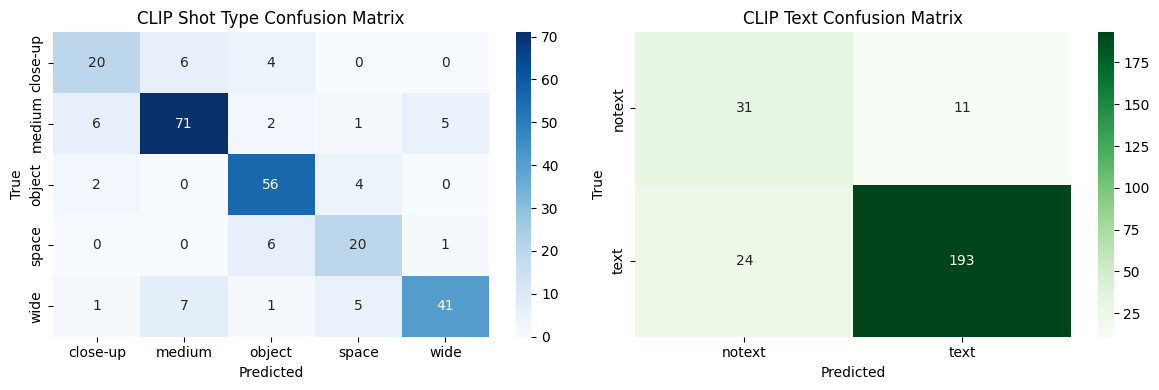

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

shot_cm = confusion_matrix(shot_true, shot_pred, labels=list(range(len(SHOT_TYPES))))
sns.heatmap(shot_cm, annot=True, fmt='d', cmap='Blues', xticklabels=SHOT_TYPES, yticklabels=SHOT_TYPES, ax=axes[0])
axes[0].set_title('CLIP Shot Type Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

text_cm = confusion_matrix(text_true, text_pred, labels=[0, 1])
sns.heatmap(text_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['notext', 'text'], yticklabels=['notext', 'text'], ax=axes[1])
axes[1].set_title('CLIP Text Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'clip_confusion_matrices.png', dpi=160)
plt.show()

In [9]:
test_result_df = df[test_mask].copy().reset_index(drop=True)
test_result_df['pred_shot_type'] = [idx_to_shot[i] for i in shot_pred]
test_result_df['pred_has_text'] = text_pred
test_result_df['shot_confidence'] = shot_conf
test_result_df['text_probability'] = text_prob
test_result_df['shot_correct'] = test_result_df['shot_type'] == test_result_df['pred_shot_type']
test_result_df['text_correct'] = test_result_df['has_text'].astype(int) == test_result_df['pred_has_text']
test_result_df['joint_correct'] = test_result_df['shot_correct'] & test_result_df['text_correct']
test_result_df.to_csv(OUTPUT_DIR / 'clip_test_predictions.csv', index=False, encoding='utf-8-sig')

display(test_result_df[['filename', 'video_id', 'shot_type', 'pred_shot_type', 'has_text', 'pred_has_text', 'shot_confidence', 'text_probability', 'joint_correct']].head(20))

,filename,video_id,shot_type,pred_shot_type,has_text,pred_has_text,shot_confidence,text_probability,joint_correct
0,0037_cut_002.jpg,37,close-up,object,0,1,0.897062,0.574719,False
1,0048_cut_027.jpg,48,close-up,close-up,0,0,0.705832,0.451168,True
2,0114_cut_001.jpg,114,close-up,close-up,0,0,0.799881,0.149876,True
3,0114_cut_015.jpg,114,close-up,close-up,0,0,0.496084,0.407413,True
4,0019_cut_002.jpg,19,close-up,medium,1,0,0.648148,0.153729,False
5,0025_cut_011.jpg,25,close-up,close-up,1,0,0.977819,0.082951,False
6,0048_cut_017.jpg,48,close-up,close-up,1,1,0.902605,0.968969,True
7,0048_cut_019.jpg,48,close-up,close-up,1,1,0.790010,0.976886,True
8,0048_cut_021.jpg,48,close-up,close-up,1,1,0.804205,0.764976,True
9,0048_cut_022.jpg,48,close-up,close-up,1,1,0.852046,0.977865,True


## 6. Compare Against the ResNet Baseline

In [10]:
resnet_metrics = {
    'shot_acc': 0.7104247104247104,
    'shot_macro_f1': 0.7071751112269045,
    'text_acc': 0.6602316602316602,
    'text_f1': 0.7621621621621621,
    'joint_acc': 0.4980694980694981,
}

comparison = pd.DataFrame([
    {'model': 'ResNet18 frozen backbone baseline', **resnet_metrics},
    {'model': 'CLIP ViT-B/32 frozen embeddings', **test_metrics},
])
comparison.to_csv(OUTPUT_DIR / 'resnet_vs_clip_comparison.csv', index=False)
comparison

,model,shot_acc,shot_macro_f1,text_acc,text_f1,joint_acc
0,ResNet18 frozen backbone baseline,0.710425,0.707175,0.660232,0.762162,0.498069
1,CLIP ViT-B/32 frozen embeddings,0.803089,0.775768,0.864865,0.916865,0.702703
